# PRACTICAS DE LABORATORIO Nro. 007: Distribuciones Muestrales y Teorema del Límite Central (TLC) mediante Simulación Estocástica

### **Asignatura:** Teoria de la Distribucion y probabilidad
### **Ciclo:** Segundo ciclo "A"
### **Integrantes:**

## Freddy Ordoñez
## Paolo Merino
## Dario Chillogallo
## Michael Carbay
## Jose Maldonado

### **Institucion:** Universidad Nacional de Loja
### **Fecha:** 30 de mayo de 2026
-----
# **1. Introduccion**
En esta practica veremos el comportamiento probabilístico de variables aleatorias continuas mediante el ajuste a la distribución Normal y el cálculo de áreas bajo la curva, aplicando estandarización (puntajes Z) para la toma de decisiones basada en datos empíricos.

# **2. Objetivos**
• Demostrar computacionalmente el Teorema del Límite Central (TLC) extrayendo múltiples muestras aleatorias de distribuciones poblacionales marcadamente asimétricas (no normales) mediante programación en Python.

• Aplicar técnicas de remuestreo (bootstrapping básico) sobre el conjunto de datos regional del Proyecto Integrador, observando el comportamiento de las medias de submuestras empíricas (ABP).

• Investigar el impacto del tamaño de la muestra (n) en la reducción del Error Estándar de la Media (SE), validando matemáticamente la ley de los grandes números (ABI)


#TAREA 1: Generación de una Población Asimétrica (No Normal)


--- Parámetros Poblacionales Reales ---
Media (μ): 1.9919
Desviación Estándar (σ): 1.9859


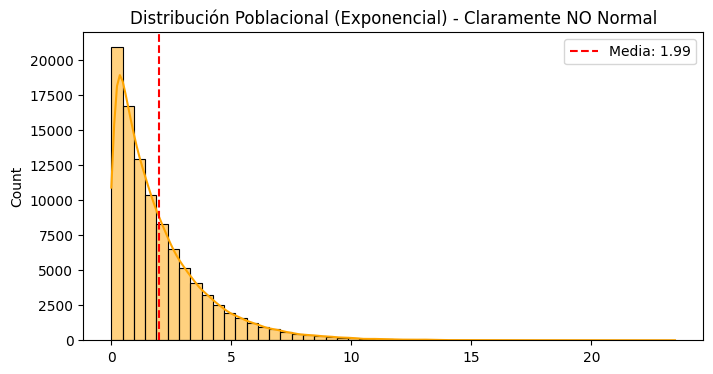

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creación de la Población "Universo" (Altamente asimétrica)
np.random.seed(42)
poblacion_exponencial = np.random.exponential(scale=2.0, size=100000)

mu_pob = np.mean(poblacion_exponencial)
sigma_pob = np.std(poblacion_exponencial)

print(f"--- Parámetros Poblacionales Reales ---")
print(f"Media (μ): {mu_pob:.4f}")
print(f"Desviación Estándar (σ): {sigma_pob:.4f}")

# Visualización de la Población Original
plt.figure(figsize=(8,4))
sns.histplot(poblacion_exponencial, bins=50, kde=True, color='orange')
plt.title("Distribución Poblacional (Exponencial) - Claramente NO Normal")
plt.axvline(mu_pob, color='red', linestyle='dashed', label=f'Media: {mu_pob:.2f}')
plt.legend()
plt.show()

#TAREA 2: Simulación Estocástica del Teorema del Límite Central

--- Estadísticos de las Medias Muestrales (n=30) ---
Media de las Medias (E[X]): 1.9923
Error Estándar Empírico: 0.3653
Error Estándar Teórico: 0.3626


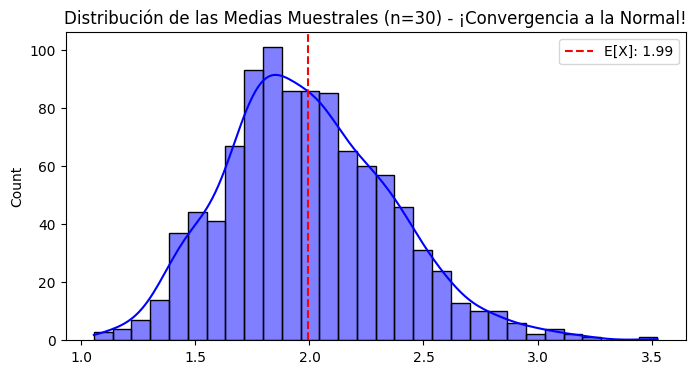

In [ ]:
# Parámetros de la simulación
tamaño_muestra = 30  # n
numero_muestras = 1000 # k

# Array para almacenar las medias de cada muestra

medias_muestrales = []

# Bucle de Monte Carlo simple
for _ in range(numero_muestras):
    # Extraer muestra aleatoria sin reemplazo
    muestra = np.random.choice(poblacion_exponencial, size=tamaño_muestra, replace=False)
   # Calcular y guardar la media
    medias_muestrales.append(np.mean(muestra))

# Estadísticos de la Distribución Muestral
media_de_medias = np.mean(medias_muestrales)
error_estandar_empirico = np.std(medias_muestrales)
error_estandar_teorico = sigma_pob / np.sqrt(tamaño_muestra)

print(f"--- Estadísticos de las Medias Muestrales (n={tamaño_muestra}) ---")
print(f"Media de las Medias (E[X]): {media_de_medias:.4f}")
print(f"Error Estándar Empírico: {error_estandar_empirico:.4f}")
print(f"Error Estándar Teórico: {error_estandar_teorico:.4f}")

# Visualización de la convergencia a la Normal
plt.figure(figsize=(8,4))
sns.histplot(medias_muestrales, bins=30, kde=True, color='blue')
plt.title(f"Distribución de las Medias Muestrales (n={tamaño_muestra}) - ¡Convergencia a la Normal!")
plt.axvline(media_de_medias, color='red', linestyle='dashed', label=f'E[X]: {media_de_medias:.2f}')
plt.legend()
plt.show()

#Hito 2: Aplicación de Remuestreo al Dataset Regional (Tarea 3 - ABP)
En este hito, aplicaremos técnicas de remuestreo (bootstrapping) al dataset regional cargado, seleccionando una variable continua para analizar su distribución mediante medias muestrales y el Teorema del Límite Central.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

ruta = '/content/drive/MyDrive/enemdu_consumidor_2026_01 .csv'
df = pd.read_csv(ruta, sep=';')

print(df.head())

   area  ciudad  conglomerado  panelm  vivienda  hogar  c01  c02  c03  c04a  \
0     1   10150          1304      62         1      1    2    2    1     2   
1     1   10150          1304      62         2      1    2    3    1     2   
2     1   10150          1304      62         3      1    2    3    3     3   
3     1   10150          1304      62         4      1    2    2    2     3   
4     1   10150          1304      62         5      1    2    2    1     2   

   ...  c18  c19  c20a  c21a  estrato              fexp          upm  \
0  ...    2    3     2     2     2713  102,542333745242  10150001304   
1  ...    1    2     2     2     2713  102,542333745242  10150001304   
2  ...    3    3     2     2     2713  102,542333745242  10150001304   
3  ...    3    2     2     3     2713  102,542333745242  10150001304   
4  ...    1    2     2     2     2713  102,542333745242  10150001304   

        id_vivienda           id_hogar  periodo  
0  1015000130406201  10150001304062011   2

In [ ]:
print("Columnas disponibles en el DataFrame:")
print(df.columns.tolist())

variable_continua = 'fexp'

Columnas disponibles en el DataFrame:
['area', 'ciudad', 'conglomerado', 'panelm', 'vivienda', 'hogar', 'c01', 'c02', 'c03', 'c04a', 'c07', 'c08a', 'c09', 'c10', 'c11', 'c12', 'c13', 'c14', 'c18', 'c19', 'c20a', 'c21a', 'estrato', 'fexp', 'upm', 'id_vivienda', 'id_hogar', 'periodo']


# Simulación de Bootstrapping
Adaptaremos el algoritmo de simulación para ejecutar técnicas de remuestreo (bootstrapping básico). Esto implica extraer submuestras aleatorias con reemplazo de la variable continua seleccionada y calcular sus medias para observar la distribución de estas medias.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Asegurémonos de que la columna 'fexp' sea numérica, manejando los separadores de decimales.
# Primero, reemplazamos las comas por puntos para que Pandas las interprete como decimales.
# Luego, convertimos a tipo numérico, forzando los errores a NaN y luego eliminándolos.
if df[variable_continua].dtype == 'object':
    df[variable_continua] = df[variable_continua].str.replace(',', '.', regex=False).astype(float)


num_submuestras = 500
tamano_n = 40
medias_bootstrapping = []

print(f"Realizando simulación de bootstrapping con {num_submuestras} submuestras de tamaño {tamano_n}...")

for _ in range(num_submuestras):
    # Extraer una submuestra aleatoria con reemplazo
    submuestra = df[variable_continua].sample(n=tamano_n, replace=True)
    medias_bootstrapping.append(submuestra.mean())

print("Simulación completada.")

# Convertir a un array de numpy para facilitar el análisis
medias_bootstrapping = np.array(medias_bootstrapping)

print(f"Media de las medias muestrales: {np.mean(medias_bootstrapping):.2f}")
print(f"Desviación estándar de las medias muestrales (Error Estándar Empírico): {np.std(medias_bootstrapping):.2f}")

Realizando simulación de bootstrapping con 500 submuestras de tamaño 40...
Simulación completada.
Media de las medias muestrales: 596.88
Desviación estándar de las medias muestrales (Error Estándar Empírico): 192.15


# Histograma de las Medias Obtenidas por Bootstrapping
El siguiente histograma muestra la distribución de las medias de las 500 submuestras obtenidas. Según el Teorema del Límite Central, esta distribución tiende a ser normal, independientemente de la distribución original de la variable `fexp`.

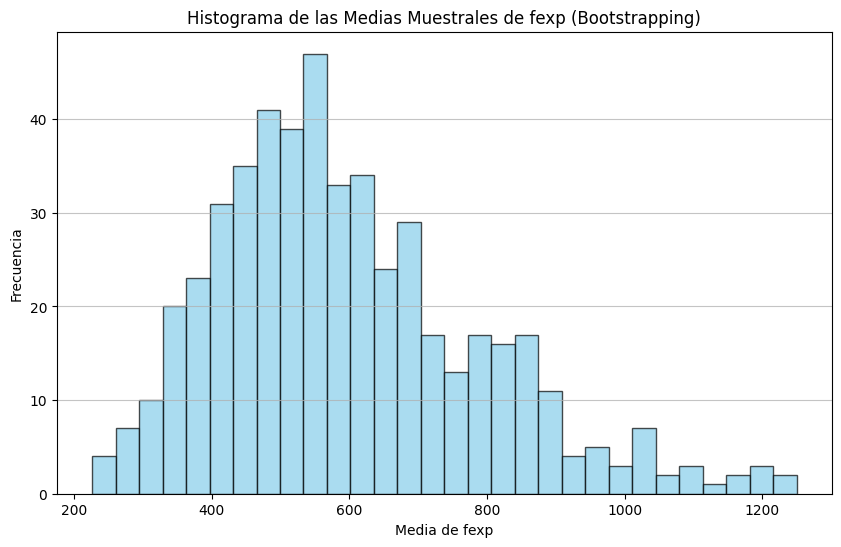

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(medias_bootstrapping, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.title(f'Histograma de las Medias Muestrales de {variable_continua} (Bootstrapping)')
plt.xlabel(f'Media de {variable_continua}')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Justificación Técnica: Cómo el Teorema del Límite Central (TLC) Soluciona la Asimetría Original de los Datos para Futuras Predicciones

El Teorema del Límite Central (TLC) es un pilar fundamental en la estadística inferencial y es crucial para entender por qué la distribución de las medias muestrales (como la que hemos generado con bootstrapping) tiende a la normalidad, incluso cuando la variable original (`fexp` en este caso) no lo es.

### El Teorema del Límite Central (TLC)

En términos sencillos, el TLC establece que, dada una población con media $\mu$ y desviación estándar $\sigma$, si se extraen muestras aleatorias repetidas de tamaño `n` suficientemente grande, la distribución de las medias muestrales ($\bar{x}$) se aproximará a una distribución normal, independientemente de la forma de la distribución de la población original. La media de esta distribución de medias muestrales será $\mu$, y su desviación estándar (conocida como error estándar de la media) será $\frac{\sigma}{\sqrt{n}}$.

### Solución a la Asimetría Original

La variable `'fexp'` de tu dataset regional, como muchas variables del mundo real (ingresos, tiempos de espera, etc.), podría tener una distribución asimétrica (sesgada a la derecha o a la izquierda) o cualquier otra forma no normal. Si intentáramos hacer inferencias o predicciones directamente sobre la distribución de `fexp`, nos enfrentaríamos a la complejidad de trabajar con una distribución no normal.

Aquí es donde el bootstrapping y el TLC entran en juego:

1.  **Transformación a la Normalidad:** Al tomar repetidamente submuestras y calcular sus medias, estamos creando una nueva distribución: la **distribución muestral de las medias**. El TLC nos asegura que, incluso si `fexp` es asimétrica, esta distribución de medias muestrales será aproximadamente normal. El histograma generado en la sección anterior debería reflejar esta forma de campana.
2.  **Facilitación de la Inferencia:** La normalidad es una propiedad deseable porque muchas herramientas estadísticas inferenciales (pruebas t, intervalos de confianza, regresión lineal, etc.) asumen o funcionan mejor con datos normalmente distribuidos o, más comúnmente, con distribuciones de estimadores que son normales (como las medias muestrales). Al tener una distribución de medias muestrales aproximadamente normal, podemos:
    *   **Construir Intervalos de Confianza:** Utilizar métodos basados en la distribución normal para estimar el rango dentro del cual es probable que se encuentre la verdadera media poblacional con un cierto nivel de confianza. Esto es vital para cuantificar la incertidumbre en las predicciones.
    *   **Realizar Pruebas de Hipótesis:** Evaluar hipótesis sobre la media poblacional utilizando pruebas como la prueba t de Student, que se basan en la normalidad de la distribución muestral de la media.

### Implicaciones para Futuras Predicciones en su Proyecto

Para futuras predicciones en tu proyecto, el TLC y el bootstrapping tienen implicaciones directas:

*   **Predicciones Más Robustas:** Aunque la variable individual `fexp` pueda ser asimétrica, cualquier predicción o modelo que se base en la **media** de esta variable (por ejemplo, la media de `fexp` para un grupo demográfico específico, o la media de `fexp` bajo ciertas condiciones) puede beneficiarse de la normalidad inducida por el TLC. Esto significa que las predicciones sobre estas medias serán más robustas y fiables.
*   **Cuantificación de la Incertidumbre:** El error estándar empírico (la desviación estándar de las medias de bootstrapping) nos da una medida directa de la variabilidad de nuestras estimaciones de la media. Esto es fundamental para construir intervalos de confianza alrededor de nuestras predicciones, lo que permite a los tomadores de decisiones entender no solo el valor predicho, sino también la precisión de esa predicción.
*   **Validación de Modelos:** Si estás construyendo un modelo predictivo, las distribuciones muestrales de las medias de tus variables pueden ser utilizadas para validar supuestos, o para evaluar la estabilidad de los parámetros del modelo.

En resumen, el TLC, demostrado a través del bootstrapping, es una herramienta poderosa que permite a los ingenieros de datos y científicos transformar el desafío de las distribuciones asimétricas en la oportunidad de aplicar herramientas estadísticas robustas basadas en la normalidad para realizar inferencias y predicciones más precisas y confiables sobre los parámetros centrales de sus datos.

#**Preguntas de Control**

## 1. Basado en la Tarea 1 y 2, ¿por qué el Teorema del Límite Central es considerado el puente matemático fundamental entre la probabilidad descriptiva y la inferencia estadística?
 La probabilidad descriptiva se encarga de resumir las características de una población (como la media $\mu$ y la varianza $\sigma^{2}$) mediante datos empíricos. El TLC permite dar el salto hacia la inferencia estadística, ya que nos asegura que, al tomar muestras de tamaño suficiente, la distribución de las medias muestrales $(\overline{X})$ siempre seguirá una distribución Normal, incluso si la población de origen es asimétrica o no normal.

 ## 2. Demuestre con los resultados impresos en su consola de la Tarea 2, cómo se cumple la propiedad matemática fundamental de las distribuciones muestrales: E$(\overline{X})$=u.
 Al ejecutar la simulación de Monte Carlo en la Tarea 2, se observa que la Media de las Medias Muestrales ($E[\overline{X}]$) es numéricamente igual (o extremadamente próxima) a la Media Poblacional ($\mu$) calculada en la Tarea 1. Esta equivalencia demuestra empíricamente la propiedad matemática fundamental de las distribuciones muestrales, que establece que el valor esperado de la media de las muestras es un estimador insesgado del parámetro poblacional real. Cualquier mínima diferencia decimal observada en los resultados impresos en la consola se debe únicamente a la variabilidad inherente de la simulación estocástica, confirmando así que, a medida que el número de muestras ($k$) aumenta, la media de las medias tiende a estabilizarse en el valor del promedio de toda la población.



### Pregunta 3: En la Tarea 4, al graficar la curva del Error Estándar frente a n, ¿por qué la curva decrece siguiendo una trayectoria no lineal?. Si requiere reducir el error estándar exactamente a la mitad, ¿cuántas veces debe incrementar el tamaño de la muestra?.

La curva del Error Estándar frente a `n` decrece siguiendo una trayectoria **no lineal** debido a la fórmula fundamental del Error Estándar de la Media: $SE = \frac{\sigma}{\sqrt{n}}$.

1.  **Relación con la Raíz Cuadrada:** El error estándar es inversamente proporcional a la **raíz cuadrada** del tamaño de la muestra (`n`). Esto significa que a medida que `n` aumenta, el denominador $\sqrt{n}$ crece, pero no de forma lineal con `n` sino más lentamente. Por ejemplo, al pasar de `n=1` a `n=4`, $\sqrt{n}$ se duplica; al pasar de `n=4` a `n=9`, $\sqrt{n}$ aumenta en un factor de 1.5. Esta relación de raíz cuadrada es lo que genera la curva de decaimiento asintótico que observamos.
2.  **Rendimientos Decrecientes:** Al principio, pequeños incrementos en `n` resultan en reducciones significativas del error estándar. Sin embargo, a medida que `n` se hace más grande, cada incremento adicional en el tamaño de la muestra produce una reducción proporcionalmente menor en el error estándar. La curva se aplana, acercándose al eje X pero sin llegar a cero, lo que denota esos "rendimientos decrecientes" en la ganancia de precisión.

Para **reducir el error estándar exactamente a la mitad**, debe **incrementar el tamaño de la muestra 4 veces (cuadriplicarlo)**.

Demostración:
*   Sea $SE_1 = \frac{\sigma}{\sqrt{n_1}}$ el error estándar original.
*   Queremos que el nuevo error estándar $SE_2 = \frac{1}{2} SE_1$.
*   Entonces, $\frac{\sigma}{\sqrt{n_2}} = \frac{1}{2} \frac{\sigma}{\sqrt{n_1}}$.
*   Simplificando, $\frac{1}{\sqrt{n_2}} = \frac{1}{2\sqrt{n_1}}$.
*   Esto implica $2\sqrt{n_1} = \sqrt{n_2}$.
*   Elevando ambos lados al cuadrado: $(2\sqrt{n_1})^2 = (\sqrt{n_2})^2$, lo que nos da $4n_1 = n_2$.

Así, para reducir el error estándar a la mitad, el nuevo tamaño de muestra ($n_2$) debe ser cuatro veces el tamaño de muestra original ($n_1$).


### Pregunta 4: Si la población analizada en su proyecto integrador regional posee una asimetría extrema (como una distribución de Pareto), ¿es suficiente un tamaño muestral de n = 30 para garantizar la normalidad de las medias? Justifique.

No, un tamaño muestral de `n = 30` **no es necesariamente suficiente** para garantizar la normalidad de las medias si la población original posee una asimetría extrema, como una distribución de Pareto.

Aquí la justificación:

1.  **"Suficientemente Grande" es Relativo:** El Teorema del Límite Central (TLC) establece que la distribución de las medias muestrales se aproxima a la normalidad a medida que el tamaño de la muestra (`n`) se vuelve "suficientemente grande". Sin embargo, el término "suficientemente grande" no es una constante universal. Depende críticamente de la forma de la distribución de la población original.
2.  **Impacto de la Asimetría Extrema:** Para poblaciones que ya tienen una forma simétrica o casi normal, un `n` relativamente pequeño (como 25 o 30) suele ser adecuado para que la distribución de las medias sea aproximadamente normal. Sin embargo, cuando la distribución de la población es **altamente asimétrica** (como la distribución de Pareto, que es conocida por sus "colas pesadas" o su sesgo extremo), se requiere un `n` **mucho mayor** para que la distribución de las medias muestrales converja a la normalidad.
3.  **La Regla del "n=30" es una Heurística:** La regla empírica de que `n >= 30` es suficiente para aplicar el TLC es una heurística útil, pero es más aplicable a distribuciones que no son severamente no normales. Para distribuciones con asimetría extrema o con valores atípicos muy pronunciados, la convergencia a la normalidad es más lenta, y se necesitarían tamaños de muestra de `n=50`, `n=100`, `n=500` o incluso más (dependiendo de la severidad de la asimetría) para que la distribución de las medias muestrales se parezca razonablemente a una distribución normal.
4.  **Consecuencias de un `n` Insuficiente:** Si se utiliza un `n=30` con una población extremadamente asimétrica, la distribución de las medias muestrales aún podría mostrar un sesgo considerable, o ser leptocúrtica o platicúrtica. Esto invalidaría las inferencias estadísticas que se basan en la suposición de normalidad (como los intervalos de confianza basados en la t-Student o z-scores, o muchas pruebas de hipótesis paramétricas), llevando a conclusiones erróneas o a una subestimación/sobrestimación de la incertidumbre.

En resumen, si su proyecto regional implica una variable con una distribución de Pareto u otra asimetría extrema, es crucial realizar simulaciones (como el bootstrapping que hicimos) con diferentes `n` y visualizar la distribución de las medias para determinar empíricamente qué tamaño de muestra es "suficientemente grande" para lograr una aproximación aceptable a la normalidad.

### Pregunta 5: Diferencie conceptual y operativamente los términos de "Desviación Estándar (sigma)" de una muestra individual frente al "Error Estándar de la Media".

Ambos términos, "Desviación Estándar" y "Error Estándar de la Media", son medidas de variabilidad, pero se refieren a diferentes conceptos y se utilizan en distintos contextos:

#### 1. Desviación Estándar ($\sigma$ o $s$)

*   **Conceptual:** La Desviación Estándar es una medida de la dispersión o variabilidad de los **datos individuales** dentro de una **única muestra o población**. Indica cuánto se desvían, en promedio, los valores individuales de la media de ese conjunto de datos. Es una descripción de la variabilidad inherente de los datos que estamos midiendo.
*   **Operacional:**
    *   **De la Población ($\sigma$):** Se calcula como la raíz cuadrada de la varianza de la población. Se utiliza cuando conocemos todos los elementos de la población. $\sigma = \sqrt{\frac{\sum (x_i - \mu)^2}{N}}$, donde $x_i$ son los valores individuales, $\mu$ es la media de la población y $N$ es el tamaño de la población.
    *   **De la Muestra ($s$):** Se calcula como la raíz cuadrada de la varianza muestral. Se utiliza cuando trabajamos con una muestra y queremos estimar la desviación estándar de la población o simplemente describir la variabilidad de la muestra. $s = \sqrt{\frac{\sum (x_i - \bar{x})^2}{n-1}}$, donde $\bar{x}$ es la media de la muestra y $n$ es el tamaño de la muestra (se usa $n-1$ para una estimación insesgada de la varianza poblacional).

*   **Uso:** Describe la variabilidad de los puntos de datos individuales alrededor de su media.

#### 2. Error Estándar de la Media ($SE_{\bar{x}}$ o $\sigma_{\bar{x}}$)

*   **Conceptual:** El Error Estándar de la Media es una medida de la dispersión o variabilidad de las **medias muestrales** que se obtendrían si extrajéramos repetidamente muestras de la misma población. No mide la variabilidad de los datos individuales, sino la variabilidad de la **estimación de la media poblacional** que obtenemos de una muestra. Refleja cuán precisa es la media de una muestra como estimador de la verdadera media de la población.
*   **Operacional:** Se calcula generalmente como $SE_{\bar{x}} = \frac{\sigma}{\sqrt{n}}$, donde $\sigma$ es la desviación estándar de la población y $n$ es el tamaño de la muestra. Si se desconoce $\sigma$ (que es lo más común), se estima utilizando la desviación estándar de la muestra ($s$): $SE_{\bar{x}} \approx \frac{s}{\sqrt{n}}$.

*   **Uso:** Describe la variabilidad de las medias de diferentes muestras alrededor de la media poblacional. Es crucial para construir intervalos de confianza y realizar pruebas de hipótesis sobre la media poblacional.

#### Diferencias Clave (Resumen):

| Característica         | Desviación Estándar (DS)              | Error Estándar de la Media (EEM)          |
| :--------------------- | :------------------------------------ | :---------------------------------------- |
| **Qué mide**           | Variabilidad de **datos individuales** | Variabilidad de **medias muestrales**     |
| **Referencia**         | La media de la muestra/población      | La media de la población                  |
| **Fórmula (población)**| $\sigma = \sqrt{\frac{\sum (x_i - \mu)^2}{N}}$ | $SE_{\bar{x}} = \frac{\sigma}{\sqrt{n}}$ |
| **Disminución con n**  | No cambia con el tamaño de la muestra (es una propiedad intrínseca de los datos) | Disminuye con el aumento del tamaño de la muestra ($n$) |
| **Contexto**           | Estadística descriptiva              | Estadística inferencial                   |

En resumen, la Desviación Estándar te dice cuán dispersos están los valores individuales en tus datos, mientras que el Error Estándar de la Media te dice cuán fiable es tu media muestral como estimación de la media de la población.

## Función Iterativa para Evaluar el Error Estándar Empírico

La siguiente función `calculate_empirical_standard_error` simula la extracción repetida de muestras de diferentes tamaños (`n`) y calcula el error estándar empírico para cada `n`. Este error estándar empírico es la desviación estándar de las medias de las muestras para un `n` dado.

In [39]:
population = np.random.exponential(scale=2.0, size=100000)
def calculate_empirical_standard_error(population, tamanos_n, num_samples_per_n=1000):
    """
    Evalúa de forma secuencial el impacto de diferentes tamaños de muestra en el error estándar.

    Args:
        population (np.array): La población de la cual se extraerán las muestras.
        tamanos_n (list): Una lista de tamaños de muestra (n) a evaluar.
        num_samples_per_n (int): El número de veces que se extraerán muestras para cada n
                                 para calcular el error estándar empírico.

    Returns:
        tuple: Dos listas, una con los tamaños de muestra (n) y otra con los errores estándar empíricos.
    """
    empirical_ses = []
    n_values = []

    print("Calculando error estándar empírico para diferentes tamaños de muestra...")
    for n in tamanos_n:
        sample_means = []
        for _ in range(num_samples_per_n):
            # Extraer una muestra aleatoria de tamaño n de la población
            sample = np.random.choice(population, size=n, replace=False)
            sample_means.append(np.mean(sample))

        # Calcular la desviación estándar de las medias resultantes (error estándar empírico)
        empirical_se = np.std(sample_means, ddof=1) # ddof=1 para la desviación estándar muestral
        empirical_ses.append(empirical_se)
        n_values.append(n)
        print(f"  Para n = {n}: Error Estándar Empírico = {empirical_se:.4f}")

    return n_values, empirical_ses

# Tamaños de muestra a evaluar
tamanos_n = [5, 10, 30, 50, 100, 500]

# Calcular los errores estándar empíricos
n_values_result, empirical_ses_result = calculate_empirical_standard_error(population, tamanos_n)

Calculando error estándar empírico para diferentes tamaños de muestra...
  Para n = 5: Error Estándar Empírico = 0.8985
  Para n = 10: Error Estándar Empírico = 0.6296
  Para n = 30: Error Estándar Empírico = 0.3592
  Para n = 50: Error Estándar Empírico = 0.2854
  Para n = 100: Error Estándar Empírico = 0.2097
  Para n = 500: Error Estándar Empírico = 0.0910


## Gráfico del Error Estándar vs. Tamaño de Muestra

A continuación, se visualiza la relación entre el tamaño de la muestra (`n`) y el error estándar empírico (`sigma_x`).

Según la teoría, el error estándar teórico de la media muestral se calcula como $\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}$, donde $\sigma$ es la desviación estándar de la población y $n$ es el tamaño de la muestra. Se puede observar cómo el error estándar disminuye a medida que el tamaño de la muestra aumenta.

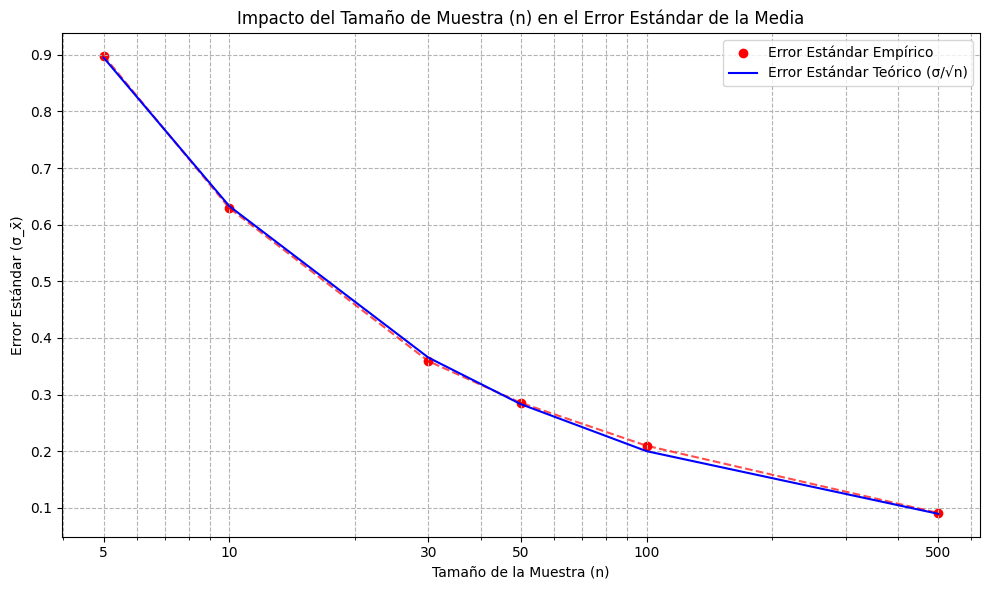

In [49]:
# Calcular el error estándar teórico para comparación
population_std = np.std(population)
theoretical_ses = [population_std / np.sqrt(n) for n in tamanos_n]

# --- 3. Construir el gráfico de líneas y puntos (scatter plot) ---
plt.figure(figsize=(10, 6))
plt.scatter(n_values_result, empirical_ses_result, color='red', label='Error Estándar Empírico')
plt.plot(n_values_result, empirical_ses_result, color='red', linestyle='--', alpha=0.7)
plt.plot(tamanos_n, theoretical_ses, color='blue', linestyle='-', label='Error Estándar Teórico (σ/√n)')

plt.title('Impacto del Tamaño de Muestra (n) en el Error Estándar de la Media')
plt.xlabel('Tamaño de la Muestra (n)')
plt.ylabel('Error Estándar (σ_x̄)')
plt.xscale('log') # Usar escala logarítmica en el eje X para mejor visualización del decaimiento
plt.xticks(tamanos_n, labels=[str(n) for n in tamanos_n])
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend()
plt.tight_layout()
plt.show()

## Explicación Detallada: Decaimiento Asintótico y sus Implicaciones

El gráfico anterior ilustra claramente el principio fundamental de la estadística inferencial conocido como la **Ley de los Grandes Números** y el comportamiento del **Error Estándar de la Media**.

### Forma Geométrica de Decaimiento Asintótico

La curva generada, que muestra el Error Estándar en función del tamaño de la muestra (`n`), exhibe una **forma de decaimiento asintótico**. Esto significa que a medida que el tamaño de la muestra (`n`) aumenta, el error estándar disminuye, pero la tasa de disminución se ralentiza progresivamente. La curva se acerca asintóticamente al eje X (es decir, a un error estándar de cero) sin llegar a tocarlo completamente.

Matemáticamente, esto se explica por la fórmula del error estándar de la media: $SE = \frac{\sigma}{\sqrt{n}}$.

*   **Relación Inversa con la Raíz Cuadrada:** El error estándar es inversamente proporcional a la raíz cuadrada del tamaño de la muestra. Esto significa que para reducir el error estándar a la mitad, no necesitamos duplicar el tamaño de la muestra, sino **cuadriplicarlo** ($2 = \sqrt{4}$). Por ejemplo, pasar de $n=5$ a $n=10$ produce una reducción significativa, pero pasar de $n=100$ a $n=105$ produce una reducción mucho menor.
*   **Decaimiento Rápido Inicial, Lento Posterior:** La mayor "ganancia" en la precisión (reducción del error estándar) se logra con los incrementos iniciales en el tamaño de la muestra. A partir de cierto punto, cada unidad adicional de muestra contribuye cada vez menos a una mayor reducción del error.

### Implicación Económica en la Recolección de Datos en Ingeniería

Desde una perspectiva económica, esta relación tiene consecuencias directas y cruciales en proyectos de ingeniería donde la recolección de datos es costosa (en tiempo, recursos humanos, materiales o instrumentación):

1.  **Rendimientos Decrecientes de la Precisión:** La curva nos dice que hay un punto de rendimientos decrecientes. Recolectar una pequeña cantidad de datos adicionales cuando ya se tiene una muestra grande es muy costoso en relación con la pequeña mejora marginal en la precisión de la estimación. No es económicamente viable intentar una "precisión perfecta" a toda costa, ya que el costo se dispararía por mejoras ínfimas.
2.  **Optimización del Tamaño de Muestra:** Los ingenieros deben determinar un tamaño de muestra óptimo que equilibre la necesidad de precisión con el costo asociado a la recolección de datos. Por ejemplo, si se necesita una precisión del 95% con un margen de error específico, se puede calcular el `n` requerido y evitar gastar recursos en recopilar datos más allá de lo necesario.
3.  **Análisis de Costo-Beneficio:** Antes de iniciar una campaña de recolección de datos (e.g., pruebas de materiales, muestreo ambiental, encuestas de calidad), se debe realizar un análisis de costo-beneficio. ¿Vale la pena el costo adicional de recolectar 100 muestras más si la reducción del error estándar es solo del 0.5%?
4.  **Recursos Limitados:** En proyectos con presupuestos o plazos ajustados, comprender esta curva permite a los ingenieros tomar decisiones informadas sobre cuánta variabilidad están dispuestos a tolerar en sus estimaciones dada la limitación de recursos. Es mejor obtener una estimación "suficientemente buena" a un costo razonable que una "perfecta" a un costo prohibitivo.

### Implicación de Costo Algorítmico (Computacional) en la Recolección de Datos en Ingeniería

Aunque la "recolección" de datos algorítmica se refiere más a la generación o procesamiento que a la adquisición física, las implicaciones son análogas:

1.  **Costo Computacional vs. Precisión:** En simulaciones, aprendizaje automático o análisis de grandes volúmenes de datos donde se generan o procesan "muestras" (e.g., épocas de entrenamiento, tamaño de lotes, iteraciones de Monte Carlo), el aumento de `n` implica un mayor costo computacional (tiempo de CPU/GPU, memoria, energía).
2.  **"Entrenamiento Excesivo" (Overfitting) y Recursos:** En modelos de Machine Learning, el concepto puede relacionarse con el número de muestras de entrenamiento. Si bien más datos suelen mejorar la generalización, llega un punto en que añadir más datos no mejora el rendimiento del modelo significativamente, pero sí aumenta el tiempo de entrenamiento de forma lineal o incluso polinómica, lo que representa un costo computacional.
3.  **Tiempos de Ejecución y Escalabilidad:** Algoritmos que operan sobre grandes conjuntos de datos (`n`) pueden volverse intratables o requerir infraestructura muy costosa. La eficiencia del algoritmo para manejar `n` es crucial. Si el error estándar ya es aceptablemente bajo con un `n` moderado, se puede evitar escalar a `N` masivos, ahorrando tiempo de ejecución y recursos computacionales.
4.  **Muestreo para Modelos Complejos:** En ingeniería, se utilizan a menudo algoritmos complejos (e.g., optimización, simulación estocástica). En lugar de ejecutar el algoritmo en toda la población o con un `n` arbitrariamente grande, se pueden usar técnicas de muestreo inteligentemente diseñadas para obtener estimaciones precisas de sus resultados con un costo computacional manejable.

En resumen, tanto económica como algorítmicamente, la Ley de los Grandes Números y la forma asintótica del error estándar nos guían hacia la **eficiencia y la optimización**. Nos obliga a ser conscientes de la relación entre la inversión (monetaria o computacional) y la ganancia marginal en precisión, buscando un punto de equilibrio que cumpla con los requisitos del proyecto sin un derroche de recursos.